In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

In [2]:
ticker = 'AAPL'
df = yf.download(ticker, start='2010-01-01')


/tmp/ipykernel_19306/4003137793.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2010-01-01')
[*********************100%***********************]  1 of 1 completed


In [3]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.400960,6.415616,6.352207,6.383612,493729600
2010-01-05,6.412027,6.448218,6.378229,6.418608,601904800
2010-01-06,6.310033,6.437448,6.303453,6.412025,552160000
2010-01-07,6.298370,6.340843,6.252609,6.333365,477131200
2010-01-08,6.340245,6.340843,6.252909,6.289997,447610800
...,...,...,...,...,...
2026-08-31,316.850006,321.239990,312.799988,319.600006,41242700
2026-09-01,325.130005,327.299988,314.730011,316.980011,53167400


<Axes: xlabel='Date'>

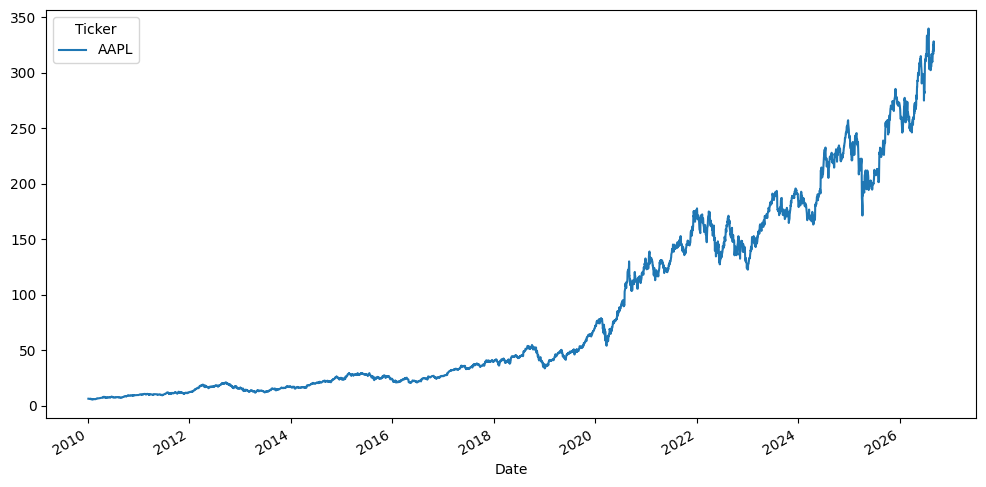

In [4]:
df.Close.plot(figsize=(12, 6))

In [5]:
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df[['Close']])


In [6]:
df.Close

Ticker,AAPL
Date,
2010-01-04,-0.942922
2010-01-05,-0.942791
2010-01-06,-0.944003
2010-01-07,-0.944142
2010-01-08,-0.943644
...,...
2026-08-31,2.747659
2026-09-01,2.846090
2026-09-02,2.844069


In [7]:
seq_length = 30

data = []

for i in range(len(df) - seq_length):
    data.append(df.Close.iloc[i:i + seq_length].values)

data = np.array(data)

if data.ndim == 2:
    data = data.reshape(data.shape[0], data.shape[1], 1)

print(data.shape)

(4164, 30, 1)


In [8]:
data

array([[[-0.94292239],
        [-0.94279082],
        [-0.94400332],
        ...,
        [-0.94837671],
        [-0.94776868],
        [-0.94669491]],

       [[-0.94279082],
        [-0.94400332],
        [-0.94414196],
        ...,
        [-0.94776868],
        [-0.94669491],
        [-0.94699713]],

       [[-0.94400332],
        [-0.94414196],
        [-0.94364417],
        ...,
        [-0.94669491],
        [-0.94699713],
        [-0.94686203]],

       ...,

       [[ 2.85178672],
        [ 2.80154439],
        [ 2.93647408],
        ...,
        [ 2.7815391 ],
        [ 2.74765857],
        [ 2.8460902 ]],

       [[ 2.80154439],
        [ 2.93647408],
        [ 2.9826782 ],
        ...,
        [ 2.74765857],
        [ 2.8460902 ],
        [ 2.84406911]],

       [[ 2.93647408],
        [ 2.9826782 ],
        [ 3.02032993],
        ...,
        [ 2.8460902 ],
        [ 2.84406911],
        [ 2.88270472]]])

In [9]:
train_size = int(len(data) * 0.8)

X_train = torch.from_numpy(data[:train_size, :-1,:]).type(torch.Tensor).to('cuda' if torch.cuda.is_available() else 'cpu')
y_train = torch.from_numpy(data[:train_size, -1,:]).type(torch.Tensor).to('cuda' if torch.cuda.is_available() else 'cpu')
X_test = torch.from_numpy(data[train_size:, :-1,:]).type(torch.Tensor).to('cuda' if torch.cuda.is_available() else 'cpu')
y_test = torch.from_numpy(data[train_size:, -1,:]).type(torch.Tensor).to('cuda' if torch.cuda.is_available() else 'cpu')



In [10]:
X_train

tensor([[[-0.9429],
         [-0.9428],
         [-0.9440],
         ...,
         [-0.9496],
         [-0.9484],
         [-0.9478]],

        [[-0.9428],
         [-0.9440],
         [-0.9441],
         ...,
         [-0.9484],
         [-0.9478],
         [-0.9467]],

        [[-0.9440],
         [-0.9441],
         [-0.9436],
         ...,
         [-0.9478],
         [-0.9467],
         [-0.9470]],

        ...,

        [[ 0.8555],
         [ 0.8324],
         [ 0.8251],
         ...,
         [ 0.9524],
         [ 0.9397],
         [ 0.9203]],

        [[ 0.8324],
         [ 0.8251],
         [ 0.8615],
         ...,
         [ 0.9397],
         [ 0.9203],
         [ 1.0113]],

        [[ 0.8251],
         [ 0.8615],
         [ 0.8801],
         ...,
         [ 0.9203],
         [ 1.0113],
         [ 1.0105]]], device='cuda:0')

In [11]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim


        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)


    def forward(self, x):
        h0 = torch.zeros(self.num_layers,x.size(0), self.hidden_dim ,device='cuda' if torch.cuda.is_available() else 'cpu')
        h1 = torch.zeros(self.num_layers,x.size(0), self.hidden_dim ,device='cuda' if torch.cuda.is_available() else 'cpu')

        out , (hn, cn) = self.lstm(x, (h0.detach(), h1.detach()))
        out =  self.fc(out[:, -1, :])
        return out
    


In [12]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to('cuda' if torch.cuda.is_available() else 'cpu')


In [13]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [14]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)

    if i % 25 == 0:
        print(i,loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


0 0.5273262858390808
25 0.00825310405343771
50 0.0007490640273317695
75 0.0006063454784452915
100 0.0005557226832024753
125 0.0005306686507537961
150 0.0005108094774186611
175 0.0004978982033208013


In [15]:
model.eval()

with torch.no_grad():
    y_train_pred = model(X_train)
    y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(
    y_train_pred.detach().cpu().numpy()
)

y_train = scaler.inverse_transform(
    y_train.detach().cpu().numpy()
)

y_test_pred = scaler.inverse_transform(
    y_test_pred.detach().cpu().numpy()
)

y_test = scaler.inverse_transform(
    y_test.detach().cpu().numpy()
)

In [16]:
train_rmse = root_mean_squared_error(y_train[:,0], y_train_pred[:,0])
test_rmse = root_mean_squared_error(y_test[:,0], y_test_pred[:,0])


In [17]:
train_rmse

1.8567218780517578

In [18]:
test_rmse

26.44575309753418

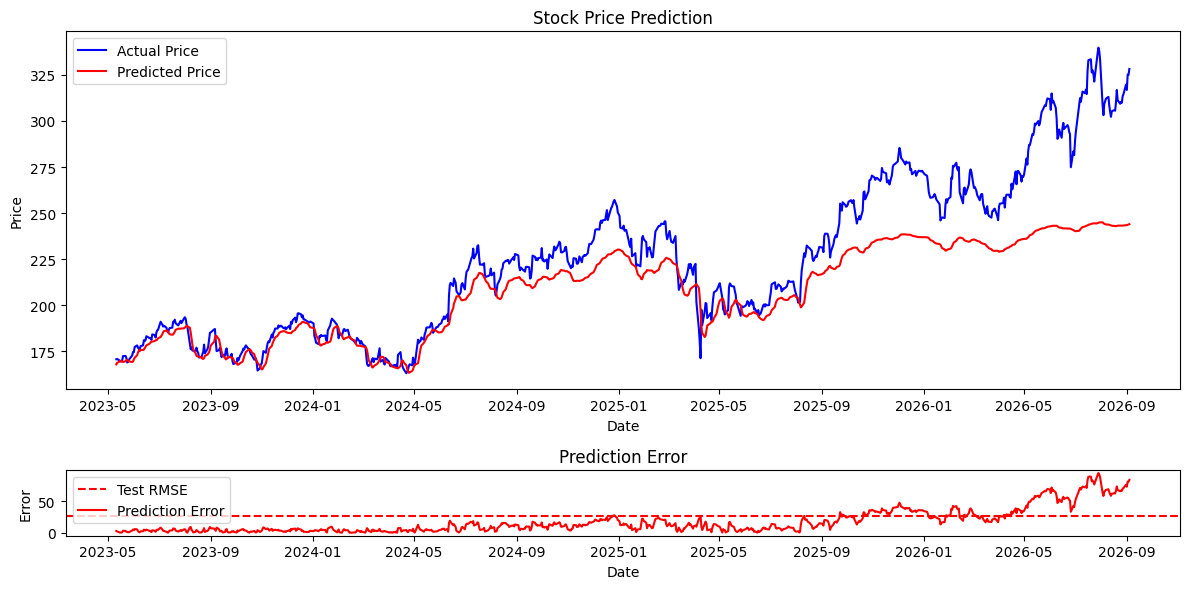

In [19]:
fig = plt.figure(figsize=(12, 6))

gs = fig.add_gridspec(4, 1)


ax1 = fig.add_subplot(gs[0:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, label='Actual Price', color='blue')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, label='Predicted Price', color='red')
ax1.legend()
plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')


ax2 =  fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color='red', linestyle='--', label='Test RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label='Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show()
